In [1]:
# Outlier Detection

In [8]:
# - Boxplot based outliers
# - IQR method
# - Z score
# - Stat comparison with & without outliers

In [9]:
%pip install -q pandas numpy seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
np.random.seed(42)

In [11]:
# Load Dataset

In [12]:
df = pd.read_csv("titanic_dataset.csv")

In [13]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [14]:
# choose features
num_cols = ["age", "fare", "sibsp", "parch"]
cat_cols = ["survived", "pclass", "sex", "embarked", "class", "who", "alone"]

print("\nNumerical columns:", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns: ['age', 'fare', 'sibsp', 'parch']
Categorical columns: ['survived', 'pclass', 'sex', 'embarked', 'class', 'who', 'alone']


In [15]:
# df with only numerical columns
df_num = df[num_cols]

In [16]:
df_num.head()

,age,fare,sibsp,parch
0,22.0,7.2500,1,0
1,38.0,71.2833,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


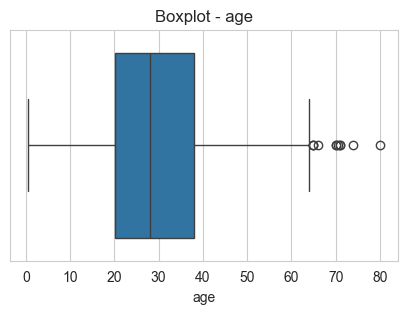

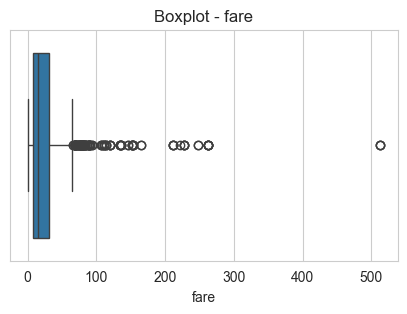

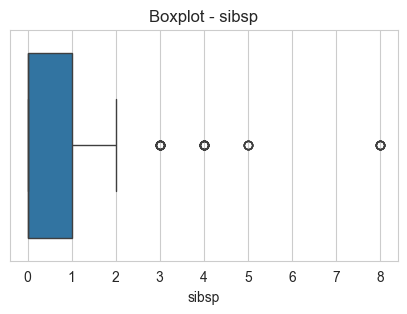

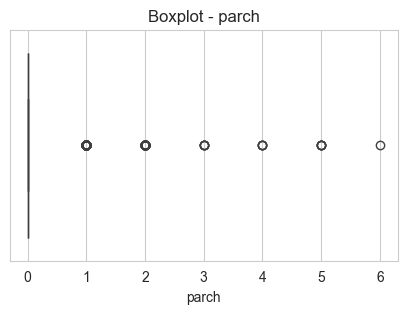

In [17]:
# Detect Outliers using boxplots
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()

In [18]:
# IQR Method

In [19]:
def iqr_bounds(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr
    return lower_bound, upper_bound, iqr

In [20]:
for col in num_cols:
    col_clean = df_num[col].dropna()
    lower, upper, iqr = iqr_bounds(col_clean)
    outliers_mask = (col_clean < lower) | (col_clean > upper)
    num_outliers = outliers_mask.sum()
    total = col_clean.shape[0]

    print(f"\nIQR method for {col}:")
    print(f" Q1 - 1.5*IQR: {lower:.2f}")
    print(f" Q3 + 1.5*IQR: {upper:.2f}")
    print(f" IQR: {iqr:.2f}")
    print(f" Outliers: {num_outliers} out of {total}")


IQR method for age:
 Q1 - 1.5*IQR: -6.69
 Q3 + 1.5*IQR: 64.81
 IQR: 17.88
 Outliers: 11 out of 714

IQR method for fare:
 Q1 - 1.5*IQR: -26.72
 Q3 + 1.5*IQR: 65.63
 IQR: 23.09
 Outliers: 116 out of 891

IQR method for sibsp:
 Q1 - 1.5*IQR: -1.50
 Q3 + 1.5*IQR: 2.50
 IQR: 1.00
 Outliers: 46 out of 891

IQR method for parch:
 Q1 - 1.5*IQR: 0.00
 Q3 + 1.5*IQR: 0.00
 IQR: 0.00
 Outliers: 213 out of 891


In [21]:
# Z-score Method

In [22]:
# |Z| = (value - mean) / std

# |Z| > 3 as outliers

In [23]:
z_threshold = 3.0

for col in num_cols:
    col_clean = df_num[col].dropna()
    mean = col_clean.mean()
    std = col_clean.std()

    z_scores = (col_clean - mean) / std
    outliers_mask = np.abs(z_scores) > z_threshold
    num_outliers = outliers_mask.sum()
    total = col_clean.shape[0]

    print(f"\nZ score method for {col}:")
    print(f" Mean: {mean:.2f}, Std: {std:.2f}")
    print(f" Threshold: |Z| > {z_threshold}")
    print(f" Outliers: {num_outliers} out of {total}")


Z score method for age:
 Mean: 29.70, Std: 14.53
 Threshold: |Z| > 3.0
 Outliers: 2 out of 714

Z score method for fare:
 Mean: 32.20, Std: 49.69
 Threshold: |Z| > 3.0
 Outliers: 20 out of 891

Z score method for sibsp:
 Mean: 0.52, Std: 1.10
 Threshold: |Z| > 3.0
 Outliers: 30 out of 891

Z score method for parch:
 Mean: 0.38, Std: 0.81
 Threshold: |Z| > 3.0
 Outliers: 15 out of 891


In [24]:
# Stat comparison with & without Outliers
fare_clean = df_num["fare"].dropna()
fare_lower, fare_upper, fare_iqr = iqr_bounds(fare_clean)

fare_inliers = fare_clean[(fare_clean >= fare_lower) & (fare_clean <= fare_upper)]

print("\nFare stats with outliers:")
print(f" Count: {fare_clean.shape[0]}")
print(f" Mean: {fare_clean.mean():.2f}")
print(f" Median: {fare_clean.median():.2f}")
print(f" Min: {fare_clean.min():.2f}, Max: {fare_clean.max():.2f}")

print("\nFare stats after removing IQR outliers:")
print(f" Count: {fare_inliers.shape[0]}")
print(f" Mean: {fare_inliers.mean():.2f}")
print(f" Median: {fare_inliers.median():.2f}")
print(f" Min: {fare_inliers.min():.2f}, Max: {fare_inliers.max():.2f}")


Fare stats with outliers:
 Count: 891
 Mean: 32.20
 Median: 14.45
 Min: 0.00, Max: 512.33

Fare stats after removing IQR outliers:
 Count: 775
 Mean: 17.82
 Median: 13.00
 Min: 0.00, Max: 65.00


In [25]:
# Summary
print("\nOutlier detection done.")
print("- Boxplots show extreme values.")
print("- IQR method highlights numeric bounds and counts.")
print("- Z score method shows extreme standardized values.")
print("- Fare stats compared with and without outliers.")


Outlier detection done.
- Boxplots show extreme values.
- IQR method highlights numeric bounds and counts.
- Z score method shows extreme standardized values.
- Fare stats compared with and without outliers.


In [26]:
# Outlier detection helps identify extreme values that can distort statistical summaries and harm model training. In the Titanic dataset:
# - Boxplots reveal clear extreme values in fare, sibsp, and parch.
# - The IQR method identifies many outliers in fare and family size features because their distributions are highly skewed.
# - Z score identifies fewer outliers and works best for normally distributed data.
# - Removing outliers significantly reduces the mean fare and compresses its range, showing how strongly outliers influence scaling.

# Overall, outlier detection prepares us for cleaner preprocessing, more stable model training, and more reliable predictions.